<a href="https://colab.research.google.com/github/siddhartha-sai-17/Machine_Learning/blob/main/Random_Forest_Classifier(Introduction).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Social_Network_Ads - Social_Network_Ads.csv to Social_Network_Ads - Social_Network_Ads.csv


In [ ]:
df = pd.read_csv('Social_Network_Ads - Social_Network_Ads.csv')

In [ ]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [ ]:
df.isnull().sum()

,0
User ID,0
Gender,0
Age,0
EstimatedSalary,0
Purchased,0


In [ ]:
X = df.iloc[:,2:4].values
y = df.iloc[:,-1].values

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators=10,criterion='entropy')
classifier.fit(X_train,y_train)

RandomForestClassifier(criterion='entropy', n_estimators=10)

In [ ]:
from sklearn.metrics import accuracy_score
y_pred = classifier.predict(X_test)
print(accuracy_score(y_pred,y_test))

0.875


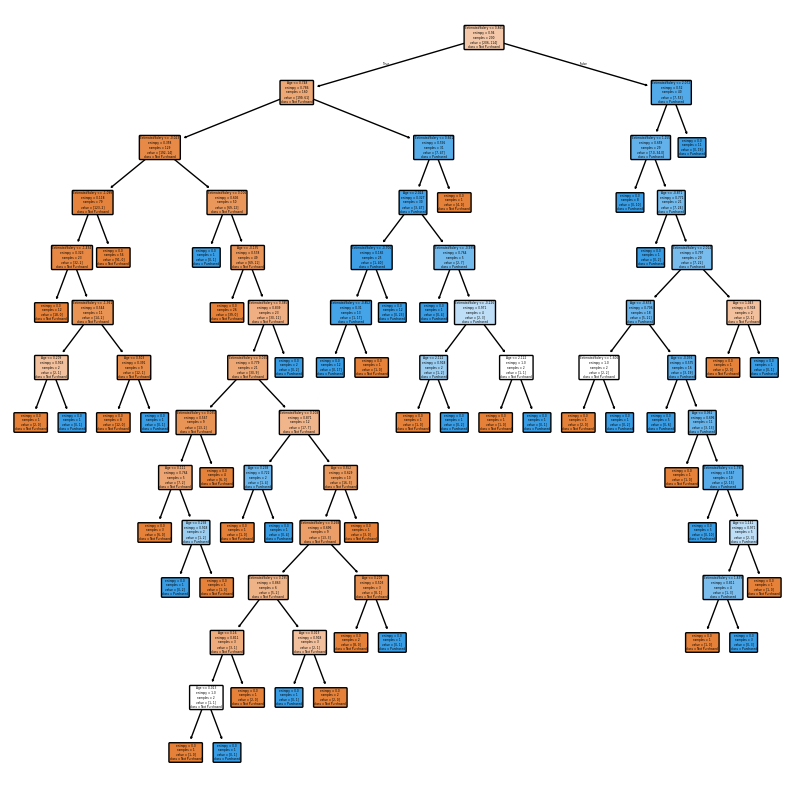

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
single_tree = classifier.estimators_[0]
plt.figure(figsize=(10,10))
plot_tree(
    single_tree,
    feature_names = ['Age','EstimatedSalary'],
    class_names = ['Not Purchased','Purchased'],
    filled = True,
    rounded = True
)
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(y_test,y_pred)
cr = classification_report(y_test,y_pred)
print(cm)
print(cr)

[[46  6]
 [ 4 24]]
              precision    recall  f1-score   support

           0       0.92      0.88      0.90        52
           1       0.80      0.86      0.83        28

    accuracy                           0.88        80
   macro avg       0.86      0.87      0.86        80
weighted avg       0.88      0.88      0.88        80

